In [1]:
import pandas as pd
import numpy as np
import glob

## 0. Data Crawling

In [2]:
REGIONS = [
    {"region": "Brussels", "latitude": 50.8503, "longitude": 4.3517},
    {"region": "Antwerp", "latitude": 51.2194, "longitude": 4.4025},
    {"region": "Ghent", "latitude": 51.0543, "longitude": 3.7174},
    {"region": "Bruges", "latitude": 51.2093, "longitude": 3.2247},
    {"region": "Liège", "latitude": 50.6326, "longitude": 5.5797},
    {"region": "Namur", "latitude": 50.4674, "longitude": 4.8720},
    {"region": "Charleroi", "latitude": 50.4108, "longitude": 4.4446},
    {"region": "Leuven", "latitude": 50.8798, "longitude": 4.7005},
    {"region": "Mons", "latitude": 50.4542, "longitude": 3.9563},
    {"region": "Hasselt", "latitude": 50.9307, "longitude": 5.3375},
    {"region": "Arlon", "latitude": 49.6835, "longitude": 5.8167},
    {"region": "Kortrijk", "latitude": 50.8279, "longitude": 3.2649},
    {"region": "Tournai", "latitude": 50.6058, "longitude": 3.3883},
    {"region": "Ostend", "latitude": 51.2254, "longitude": 2.9263},
    {"region": "Wavre", "latitude": 50.7159, "longitude": 4.6105},
]

ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"
FORECAST_URL = "https://api.open-meteo.com/v1/forecast"

HOURLY_VARS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "wind_speed_10m",
    "wind_direction_10m",
    "pressure_msl",
    "cloud_cover",
]

## 1. Data Preprocessing

### 1.1 Traffic count

In [3]:
#Loading traffic data
traffic_columns=['site_id', 'direction', 'type', 'from', 'to', 'count']
traffic_files = sorted(glob.glob("/home/test/mda/mda_project/data/traffic/data-*.csv"))
df_traffic = pd.concat([pd.read_csv(f, header=None, names=traffic_columns) for f in traffic_files], ignore_index=True)

In [4]:
df_traffic.shape

(41344152, 6)

In [5]:
df_traffic = df_traffic[df_traffic['count'].isna() == False]

In [6]:
print(f"{len(df_traffic):,} rows from {len(traffic_files)} files")

40,275,581 rows from 80 files


In [7]:
df_traffic["from"] = pd.to_datetime(df_traffic["from"])
df_traffic["to"]   = pd.to_datetime(df_traffic["to"])

df_traffic["year"]   = df_traffic["from"].dt.year
df_traffic["month"]  = df_traffic["from"].dt.month
df_traffic["day"]    = df_traffic["from"].dt.day
df_traffic["hour"]   = df_traffic["from"].dt.hour
df_traffic["minute"] = df_traffic["from"].dt.minute

df_traffic.info()

<class 'pandas.DataFrame'>
Index: 40275581 entries, 0 to 41344151
Data columns (total 11 columns):
 #   Column     Dtype         
---  ------     -----         
 0   site_id    int64         
 1   direction  str           
 2   type       str           
 3   from       datetime64[us]
 4   to         datetime64[us]
 5   count      float64       
 6   year       int32         
 7   month      int32         
 8   day        int32         
 9   hour       int32         
 10  minute     int32         
dtypes: datetime64[us](2), float64(1), int32(5), int64(1), str(2)
memory usage: 2.9 GB


In [8]:
quarter_map = {0: "00_15", 15: "15_30", 30: "30_45", 45: "45_60"}
df_traffic["quarter"] = df_traffic["from"].dt.minute.map(quarter_map)
df_traffic.head()

,site_id,direction,type,from,to,count,year,month,day,hour,minute,quarter
0,1,IN,FIETSERS,2019-08-01 00:00:00,2019-08-01 00:15:00,0.0,2019,8,1,0,0,00_15
1,1,IN,FIETSERS,2019-08-01 00:15:00,2019-08-01 00:30:00,0.0,2019,8,1,0,15,15_30
2,1,IN,FIETSERS,2019-08-01 00:30:00,2019-08-01 00:45:00,0.0,2019,8,1,0,30,30_45
3,1,IN,FIETSERS,2019-08-01 00:45:00,2019-08-01 01:00:00,0.0,2019,8,1,0,45,45_60
4,1,IN,FIETSERS,2019-08-01 01:00:00,2019-08-01 01:15:00,1.0,2019,8,1,1,0,00_15


In [9]:

df_traffic["site_id"]   = df_traffic["site_id"].astype("int32")
df_traffic["count"]     = df_traffic["count"].astype("float32")
df_traffic["direction"] = df_traffic["direction"].astype("category")
df_traffic["type"]      = df_traffic["type"].astype("category")
df_traffic["quarter"]   = df_traffic["quarter"].astype("category")

print(f"Sau khi optimize: {df_traffic.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Sau khi optimize: 2.22 GB


In [10]:
df_traffic_hourly = df_traffic.pivot_table(
    index=["site_id", "year","month","day", "hour","type"],
    columns=["direction", "quarter"],
    values="count",
    aggfunc="sum",
    fill_value=0,
)  
df_traffic_hourly.columns = [f"{d}_{q}" for d, q in df_traffic_hourly.columns]
df_traffic_hourly = df_traffic_hourly.reset_index()
df_traffic_hourly.head()

,site_id,year,month,day,hour,type,IN_00_15,IN_15_30,IN_30_45,IN_45_60,OUT_00_15,OUT_15_30,OUT_30_45,OUT_45_60
0,1,2019,8,1,0,FIETSERS,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1,2019,8,1,1,FIETSERS,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,2019,8,1,2,FIETSERS,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1,2019,8,1,3,FIETSERS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,2019,8,1,4,FIETSERS,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [11]:
df_traffic_hourly.shape

(5043289, 14)

In [14]:
#Feature Engineering
count_cols = [c for c in df_traffic_hourly.columns if c not in ("site_id", "year", "month", "day", "hour", "type")]
in_cols    = [c for c in count_cols if c.startswith("IN_")]
out_cols   = [c for c in count_cols if c.startswith("OUT_")]

df_traffic_hourly["total_in"]   = df_traffic_hourly[in_cols].sum(axis=1)
df_traffic_hourly["total_out"]  = df_traffic_hourly[out_cols].sum(axis=1)
df_traffic_hourly["total"]      = df_traffic_hourly["total_in"] + df_traffic_hourly["total_out"]
df_traffic_hourly["net_flow"]   = df_traffic_hourly["total_in"] - df_traffic_hourly["total_out"]

df_traffic_hourly["min_q"]      = df_traffic_hourly[count_cols].min(axis=1)
df_traffic_hourly["max_q"]      = df_traffic_hourly[count_cols].max(axis=1)
df_traffic_hourly["mean_q"]     = df_traffic_hourly[count_cols].mean(axis=1)
df_traffic_hourly["median_q"]   = df_traffic_hourly[count_cols].median(axis=1)
df_traffic_hourly["std_q"]      = df_traffic_hourly[count_cols].std(axis=1)
df_traffic_hourly["range_q"]    = df_traffic_hourly["max_q"] - df_traffic_hourly["min_q"]

# Thêm date features
df_traffic_hourly["datehour"] = pd.to_datetime(df_traffic_hourly[["year", "month", "day", "hour"]])
df_traffic_hourly["date"] = pd.to_datetime(df_traffic_hourly[["year", "month", "day"]])
df_traffic_hourly["dayofweek"]   = df_traffic_hourly["date"].dt.dayofweek      # 0=Mon, 6=Sun
df_traffic_hourly["is_weekend"]  = df_traffic_hourly["dayofweek"].isin([5, 6]).astype(int)

print(df_traffic_hourly.head())
print("Shape:", df_traffic_hourly.shape)
print("Columns:", df_traffic_hourly.columns.tolist())

   site_id  year  month  day  hour      type  IN_00_15  IN_15_30  IN_30_45  \
0        1  2019      8    1     0  FIETSERS       0.0       0.0       0.0   
1        1  2019      8    1     1  FIETSERS       1.0       0.0       0.0   
2        1  2019      8    1     2  FIETSERS       0.0       0.0       1.0   
3        1  2019      8    1     3  FIETSERS       0.0       0.0       0.0   
4        1  2019      8    1     4  FIETSERS       0.0       0.0       0.0   

   IN_45_60  ...  min_q  max_q    mean_q  median_q     std_q  range_q  \
0       0.0  ...   -2.0    2.0  0.333333       0.0  1.073087      4.0   
1       0.0  ...    0.0    1.0  0.333333       0.0  0.492366      1.0   
2       0.0  ...    0.0    1.0  0.333333       0.0  0.492366      1.0   
3       0.0  ...    0.0    0.0  0.000000       0.0  0.000000      0.0   
4       0.0  ...   -2.0    2.0  0.333333       0.0  1.073087      4.0   

             datehour       date  dayofweek  is_weekend  
0 2019-08-01 00:00:00 2019-08-01  

In [15]:
df_traffic_hourly.head()

,site_id,year,month,day,hour,type,IN_00_15,IN_15_30,IN_30_45,IN_45_60,...,min_q,max_q,mean_q,median_q,std_q,range_q,datehour,date,dayofweek,is_weekend
0,1,2019,8,1,0,FIETSERS,0.0,0.0,0.0,0.0,...,-2.0,2.0,0.333333,0.0,1.073087,4.0,2019-08-01 00:00:00,2019-08-01,3,0
1,1,2019,8,1,1,FIETSERS,1.0,0.0,0.0,0.0,...,0.0,1.0,0.333333,0.0,0.492366,1.0,2019-08-01 01:00:00,2019-08-01,3,0
2,1,2019,8,1,2,FIETSERS,0.0,0.0,1.0,0.0,...,0.0,1.0,0.333333,0.0,0.492366,1.0,2019-08-01 02:00:00,2019-08-01,3,0
3,1,2019,8,1,3,FIETSERS,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,2019-08-01 03:00:00,2019-08-01,3,0
4,1,2019,8,1,4,FIETSERS,0.0,0.0,0.0,0.0,...,-2.0,2.0,0.333333,0.0,1.073087,4.0,2019-08-01 04:00:00,2019-08-01,3,0


### 1.2. Richtingen

In [16]:
richtingen_columns=['site_id', 'direction', 'name']
df_richtingen = pd.read_csv('/home/test/mda/mda_project/data/richtingen.csv', header=0, names=richtingen_columns)
df_richtingen.head()

,site_id,direction,name
0,1,OUT,Machelen Cyclists richting Machelen
1,2,IN,Brasschaat 2 Fietsers rich Merksem
2,2,OUT,Brasschaat 2 Fietsers rich Brasschaat
3,3,IN,Brasschaat 1 Fietsers rich Merksem
4,3,OUT,Brasschaat 1 Fietsers rich Brasschaat


In [17]:
df_richtingen.info()
df_richtingen.shape

<class 'pandas.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   site_id    304 non-null    int64
 1   direction  304 non-null    str  
 2   name       304 non-null    str  
dtypes: int64(1), str(2)
memory usage: 7.3 KB


(304, 3)

In [18]:
df_richtingen = df_richtingen[df_richtingen['direction'].isin(['IN', 'OUT'])]
df_richtingen.shape

(300, 3)

### 1.3. Sites

In [19]:
sites_columns=['site_id', 'site_nr', 'longtitude', 'latitude', 'name', 'domain', 'road_nbr','district_nbr', 'municipality', 'interval', 'date_installed']
df_sites = pd.read_csv('/home/test/mda/mda_project/data/sites.csv', header=0, names=sites_columns)
df_sites.head()

,site_id,site_nr,longtitude,latitude,name,domain,road_nbr,district_nbr,municipality,interval,date_installed
0,2,100052862,4.47169,51.27512,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22
1,3,100052863,4.47222,51.27503,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,2019-08-22
2,4,100052864,5.19011,51.16023,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22
3,5,100052865,5.19003,51.16018,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22
4,6,100052866,3.70298,51.10894,Evergem 2,Vlaamse Overheid A. Wegen enVerkeer,N4560001,AWV413,Evergem,15,2019-08-22


In [20]:

REGIONS_DF = pd.DataFrame(REGIONS)

def haversine_km(lat1, lon1, lat2, lon2):
    """Khoảng cách Haversine (km), nhận numpy arrays để vector hóa."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 2 * R * np.arcsin(np.sqrt(a))

# Ma trận khoảng cách: 150 sites × 15 regions
site_lat = df_sites["latitude"].to_numpy()[:, None]    # cột (150, 1)
site_lon = df_sites["longtitude"].to_numpy()[:, None]
reg_lat  = REGIONS_DF["latitude"].to_numpy()[None, :]  # hàng (1, 15)
reg_lon  = REGIONS_DF["longitude"].to_numpy()[None, :]

dist = haversine_km(site_lat, site_lon, reg_lat, reg_lon)   # shape (150, 15)

# Với mỗi site, chọn region gần nhất
nearest_idx = dist.argmin(axis=1)
df_sites["region"]         = REGIONS_DF["region"].to_numpy()[nearest_idx]
df_sites["region_dist_km"] = dist[np.arange(len(df_sites)), nearest_idx].round(2)

print(df_sites[["site_id", "name", "latitude", "longtitude",
                "region", "region_dist_km"]].head(15))

    site_id                 name  latitude  longtitude    region  \
0         2         Brasschaat 2  51.27512     4.47169   Antwerp   
1         3         Brasschaat 1  51.27503     4.47222   Antwerp   
2         4              Balen 1  51.16023     5.19011   Hasselt   
3         5              Balen 2  51.16018     5.19003   Hasselt   
4         6            Evergem 2  51.10894     3.70298     Ghent   
5         7            Evergem 1  51.10890     3.70317     Ghent   
6         8  Heist op den Berg 1  51.06759     4.68823    Leuven   
7         9  Heist op den Berg 2  51.06904     4.69524    Leuven   
8        10              Aalst 2  50.93549     4.01571     Ghent   
9        11              Aalst 3  50.93385     4.01647     Ghent   
10       12             Tervuren  50.81896     4.47803  Brussels   
11       13                 Gent  51.03018     3.70146     Ghent   
12       14                 Genk  50.97172     5.48927   Hasselt   
13       15           Oostende 2  51.21371     2

In [21]:
df_sites.shape

(150, 13)

In [22]:
df_sites.head()

,site_id,site_nr,longtitude,latitude,name,domain,road_nbr,district_nbr,municipality,interval,date_installed,region,region_dist_km
0,2,100052862,4.47169,51.27512,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22,Antwerp,7.85
1,3,100052863,4.47222,51.27503,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,2019-08-22,Antwerp,7.86
2,4,100052864,5.19011,51.16023,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22,Hasselt,27.52
3,5,100052865,5.19003,51.16018,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22,Hasselt,27.52
4,6,100052866,3.70298,51.10894,Evergem 2,Vlaamse Overheid A. Wegen enVerkeer,N4560001,AWV413,Evergem,15,2019-08-22,Ghent,6.16


### 1.4 Weather

In [23]:
df_weather = pd.read_csv('/home/test/mda/belgium_weather_2019_2026.csv', header=0)
df_weather.head()

,region,latitude,longitude,datetime,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,wind_direction_10m,pressure_msl,cloud_cover
0,Brussels,50.8503,4.3517,2019-08-01T00:00,15.9,74,0.0,0.0,0.0,13.0,214,1016.9,63
1,Brussels,50.8503,4.3517,2019-08-01T01:00,15.9,76,0.0,0.0,0.0,12.1,217,1017.1,56
2,Brussels,50.8503,4.3517,2019-08-01T02:00,15.4,80,0.0,0.0,0.0,12.6,211,1017.5,86
3,Brussels,50.8503,4.3517,2019-08-01T03:00,15.3,82,0.0,0.0,0.0,13.7,210,1017.2,76
4,Brussels,50.8503,4.3517,2019-08-01T04:00,15.9,79,0.0,0.0,0.0,15.5,216,1016.7,96


In [24]:
df_weather = df_weather.rename(columns={"datetime": "datehour"})
df_weather["datehour"] = pd.to_datetime(df_weather["datehour"])

df_weather.head()

,region,latitude,longitude,datehour,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,wind_direction_10m,pressure_msl,cloud_cover
0,Brussels,50.8503,4.3517,2019-08-01 00:00:00,15.9,74,0.0,0.0,0.0,13.0,214,1016.9,63
1,Brussels,50.8503,4.3517,2019-08-01 01:00:00,15.9,76,0.0,0.0,0.0,12.1,217,1017.1,56
2,Brussels,50.8503,4.3517,2019-08-01 02:00:00,15.4,80,0.0,0.0,0.0,12.6,211,1017.5,86
3,Brussels,50.8503,4.3517,2019-08-01 03:00:00,15.3,82,0.0,0.0,0.0,13.7,210,1017.2,76
4,Brussels,50.8503,4.3517,2019-08-01 04:00:00,15.9,79,0.0,0.0,0.0,15.5,216,1016.7,96


### 1.5. Population

In [25]:
import rasterio
from rasterio.mask import geometry_mask
from rasterio.sample import sample_gen
import matplotlib.pyplot as plt

In [26]:
TIF_PATH = "/home/test/mda/mda_project/data/extra/bel_pop_2025_CN_100m_R2025A_v1.tif"

# Open the file and extract all values at once
with rasterio.open(TIF_PATH) as src:
      print(f"CRS: {src.crs}")
      print(f"Bounds: {src.bounds}")
      print(f"Shape: {src.shape}")

      # Extract raster values for all sites (lat/long pairs)
      coords = list(zip(df_sites['longtitude'], df_sites['latitude']))

      # Sample the raster at all coordinates
      sampled_values = list(sample_gen(src, coords))

      # Get first band from each sampled point
      # df_sites['population'] = [val[0] for val in sampled_values]

# # Now merge with traffic data
# df_traffic_with_pop = df_traffic.merge(
#       df_sites,
#       left_on='site_id',
#       right_on='site_id',
#       how='left'
#   )

# print(df_traffic_with_pop.head())
# print(f"Population stats: {df_traffic_with_pop['population'].describe()}")

CRS: EPSG:4326
Bounds: BoundingBox(left=2.5458326031499974, bottom=49.49750013801, right=6.407499254369998, top=51.50416679665)
Shape: (2408, 4634)


Size (rows, cols): (2408, 4634)
Number of bands              : 1
Data types          : ('float32',)
CRS       : EPSG:4326
Bounds       : BoundingBox(left=2.5458326031499974, bottom=49.49750013801, right=6.407499254369998, top=51.50416679665)
Resolution    : (0.00083333333, 0.00083333333)
NoData value:        -99999.0
Total estimated population: 11749843.0
Shape band 1: (2408, 4634)
Min/Max values: 0.0 461.33267


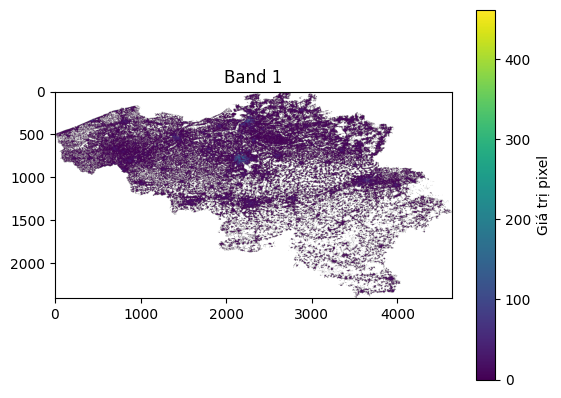

In [27]:
with rasterio.open(TIF_PATH) as src:
    print("Size (rows, cols):", src.shape)
    print("Number of bands              :", src.count)
    print("Data types          :", src.dtypes)
    print("CRS       :", src.crs)
    print("Bounds       :", src.bounds)
    print("Resolution    :", src.res)
    print("NoData value:       ", src.nodata)

    # Read all data
    pop = src.read(1,masked=True)
    print("Total estimated population:", float(pop.sum()))
    # Read only band 1 (population)
    band1 = src.read(1,masked=True)

print("Shape band 1:", band1.shape)
print("Min/Max values:", band1.min(), band1.max())

# Visualize the population raster
plt.imshow(band1, cmap="viridis")
plt.colorbar(label="Giá trị pixel")
plt.title("Band 1")
plt.show()

### Calculate population using buffer

In [28]:
import math
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point
from shapely.ops import transform
from pyproj import Transformer


METRIC_CRS = "EPSG:3035"   

def population_estimate(lat, lon, radius_m, tif_path=TIF_PATH):
    
    with rasterio.open(tif_path) as src:
        # 1. Covert (lat, lon) to m for accurate buffering
        to_metric = Transformer.from_crs("EPSG:4326", METRIC_CRS, always_xy=True)
        x_m, y_m = to_metric.transform(lon, lat)

        # 2. Create circle with radius_m meters
        circle = Point(x_m, y_m).buffer(radius_m)

        # 3. Transform circle to raster's CRS for masking
        to_raster = Transformer.from_crs(METRIC_CRS, src.crs, always_xy=True)
        circle_in_raster = transform(to_raster.transform, circle)

        # 4. Cut raster by circle, mask NoData automatically
        out, _ = mask(src, [circle_in_raster], crop=True, filled=False)

        total_pop = float(out.sum())                       # total population in the circle
        area_km2  = math.pi * (radius_m ** 2) / 1e6        # area of the circle in km²
        density   = total_pop / area_km2                   # population density in people/km²
        return total_pop, density, area_km2

rows = []
for loc in REGIONS:
    name, lat, lon = loc["region"], loc["latitude"], loc["longitude"]
    row = {"region": name, "latitude": lat, "longitude": lon}
    for r in (1000, 5000, 10000):
        pop, dens, area = population_estimate(lat, lon, r)
        row[f"pop_{r}m"] = round(pop, 1)
        row[f"density_{r}m"] = round(dens, 1)
    rows.append(row)

df_population = pd.DataFrame(rows)
print(df_population)

       region  latitude  longitude  pop_1000m  density_1000m  pop_5000m  \
0    Brussels   50.8503     4.3517    40678.9        12948.5   956720.0   
1     Antwerp   51.2194     4.4025    25744.2         8194.6   411475.3   
2       Ghent   51.0543     3.7174    23853.8         7592.9   243205.8   
3      Bruges   51.2093     3.2247    17820.3         5672.4   111332.0   
4       Liège   50.6326     5.5797    24378.5         7759.9   252092.4   
5       Namur   50.4674     4.8720    15246.3         4853.0    89321.4   
6   Charleroi   50.4108     4.4446    15337.8         4882.2   182287.8   
7      Leuven   50.8798     4.7005    23757.8         7562.4   122816.3   
8        Mons   50.4542     3.9563    13992.8         4454.0    74604.0   
9     Hasselt   50.9307     5.3375    17438.0         5550.7    68832.7   
10      Arlon   49.6835     5.8167    11208.0         3567.6    27746.5   
11   Kortrijk   50.8279     3.2649    15481.2         4927.8   112430.8   
12    Tournai   50.6058  

In [29]:
df_sites_with_pop = df_sites.merge(df_population, on="region", how="left")
print(df_sites_with_pop.head())

   site_id    site_nr  longtitude  latitude_x          name  \
0        2  100052862     4.47169    51.27512  Brasschaat 2   
1        3  100052863     4.47222    51.27503  Brasschaat 1   
2        4  100052864     5.19011    51.16023       Balen 1   
3        5  100052865     5.19003    51.16018       Balen 2   
4        6  100052866     3.70298    51.10894     Evergem 2   

                                domain  road_nbr district_nbr municipality  \
0  Vlaamse Overheid A. Wegen enVerkeer  N0010002       AWV123   Brasschaat   
1  Vlaamse Overheid A. Wegen enVerkeer  N0010001       AWV123   Brasschaat   
2  Vlaamse Overheid A. Wegen enVerkeer  N0180002       AWV114        Balen   
3  Vlaamse Overheid A. Wegen enVerkeer  N0180002       AWV114        Balen   
4  Vlaamse Overheid A. Wegen enVerkeer  N4560001       AWV413      Evergem   

   interval  ...   region region_dist_km  latitude_y  longitude  pop_1000m  \
0        15  ...  Antwerp           7.85     51.2194     4.4025    25744.2

In [30]:
df_sites_with_pop.head()

,site_id,site_nr,longtitude,latitude_x,name,domain,road_nbr,district_nbr,municipality,interval,...,region,region_dist_km,latitude_y,longitude,pop_1000m,density_1000m,pop_5000m,density_5000m,pop_10000m,density_10000m
0,2,100052862,4.47169,51.27512,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,...,Antwerp,7.85,51.2194,4.4025,25744.2,8194.6,411475.3,5239.1,749287.9,2385.1
1,3,100052863,4.47222,51.27503,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,...,Antwerp,7.86,51.2194,4.4025,25744.2,8194.6,411475.3,5239.1,749287.9,2385.1
2,4,100052864,5.19011,51.16023,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,...,Hasselt,27.52,50.9307,5.3375,17438.0,5550.7,68832.7,876.4,169978.5,541.1
3,5,100052865,5.19003,51.16018,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,...,Hasselt,27.52,50.9307,5.3375,17438.0,5550.7,68832.7,876.4,169978.5,541.1
4,6,100052866,3.70298,51.10894,Evergem 2,Vlaamse Overheid A. Wegen enVerkeer,N4560001,AWV413,Evergem,15,...,Ghent,6.16,51.0543,3.7174,23853.8,7592.9,243205.8,3096.6,388644.0,1237.1


### 1.6. Datetime 

In [31]:
# Build datetime features: one row per (site_id, datehour)
df_traffic["datehour"] = df_traffic["from"].dt.floor("h")
dt = df_traffic[["site_id", "datehour"]].drop_duplicates().copy()

dt["year"]      = dt["datehour"].dt.year
dt["month"]     = dt["datehour"].dt.month
dt["day"]       = dt["datehour"].dt.day
dt["hour"]      = dt["datehour"].dt.hour
dt["dayofweek"] = dt["datehour"].dt.dayofweek

# Weekday / weekend
dt["dt_is_weekend"] = dt["dayofweek"].isin([5, 6]).astype(int)
dt["dt_is_weekday"] = 1 - dt["dt_is_weekend"]

# Specific days
dt["dt_is_monday"] = (dt["dayofweek"] == 0).astype(int)
dt["dt_is_friday"] = (dt["dayofweek"] == 4).astype(int)

# Hour-of-day buckets
dt["dt_is_morning_rush"]   = dt["hour"].isin([7, 8, 9]).astype(int)
dt["dt_is_afternoon_rush"] = dt["hour"].isin([16, 17, 18]).astype(int)
dt["dt_is_rush_hour"]      = (dt["dt_is_morning_rush"] | dt["dt_is_afternoon_rush"]).astype(int)
dt["dt_is_lunch_hour"]     = dt["hour"].isin([12, 13]).astype(int)
dt["dt_is_night"]          = dt["hour"].isin([0, 1, 2, 3, 4, 5]).astype(int)
dt["dt_is_business_hours"] = (dt["hour"].between(9, 17) & (dt["dt_is_weekday"] == 1)).astype(int)

# Public holiday placeholder 
dt["dt_is_public_holiday"] = 0
dt["dt_public_holiday"]    = "None"

df_datetime = dt
print("Datetime features shape:", df_datetime.shape)
df_datetime.head()


Datetime features shape: (5043289, 19)


,site_id,datehour,year,month,day,hour,dayofweek,dt_is_weekend,dt_is_weekday,dt_is_monday,dt_is_friday,dt_is_morning_rush,dt_is_afternoon_rush,dt_is_rush_hour,dt_is_lunch_hour,dt_is_night,dt_is_business_hours,dt_is_public_holiday,dt_public_holiday
0,1,2019-08-01 00:00:00,2019,8,1,0,3,0,1,0,0,0,0,0,0,1,0,0,None
4,1,2019-08-01 01:00:00,2019,8,1,1,3,0,1,0,0,0,0,0,0,1,0,0,None
8,1,2019-08-01 02:00:00,2019,8,1,2,3,0,1,0,0,0,0,0,0,1,0,0,None
12,1,2019-08-01 03:00:00,2019,8,1,3,3,0,1,0,0,0,0,0,0,1,0,0,None
16,1,2019-08-01 04:00:00,2019,8,1,4,3,0,1,0,0,0,0,0,0,1,0,0,None


### 1.7. Site features

In [32]:
# Build site features: static road type + per-(site, hour) sensor age
sites = df_sites.copy()
sites["install_date"] = pd.to_datetime(sites["date_installed"], errors="coerce")

road = sites["road_nbr"].astype(str).str.upper()
sites["site_is_road_tunnel"]   = road.str.contains("TUNNEL", na=False).astype(int)
sites["site_is_road_national"] = road.str.startswith("N", na=False).astype(int)
sites["site_is_road_ring"]     = road.str.startswith("R", na=False).astype(int)
sites["site_is_road_motorway"] = road.str.startswith("A", na=False).astype(int)

# Expand to (site_id, datehour) so sensor_age can be computed per hour
df_fts_site = (
    df_traffic[["site_id", "datehour"]]
    .drop_duplicates()
    .merge(
        sites[["site_id", "install_date",
               "site_is_road_tunnel", "site_is_road_national",
               "site_is_road_ring", "site_is_road_motorway"]],
        on="site_id", how="left",
    )
)

df_fts_site["site_sensor_age"] = (
    (df_fts_site["datehour"] - df_fts_site["install_date"]).dt.days / 365.25
)

df_fts_site = df_fts_site[[
    "site_id", "datehour", "site_sensor_age",
    "site_is_road_tunnel", "site_is_road_national",
    "site_is_road_ring", "site_is_road_motorway",
]]

print("Site features shape:", df_fts_site.shape)
df_fts_site.head()


Site features shape: (5043289, 7)


,site_id,datehour,site_sensor_age,site_is_road_tunnel,site_is_road_national,site_is_road_ring,site_is_road_motorway
0,1,2019-08-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1,1,2019-08-01 01:00:00,NaN,NaN,NaN,NaN,NaN
2,1,2019-08-01 02:00:00,NaN,NaN,NaN,NaN,NaN
3,1,2019-08-01 03:00:00,NaN,NaN,NaN,NaN,NaN
4,1,2019-08-01 04:00:00,NaN,NaN,NaN,NaN,NaN


### 1.8. Infrastructure (to be updated)

### 1.9. Strava (to be updated)

## 2. Feature Engineering

In [33]:
df_traffic_hourly.shape

(5043289, 28)

In [36]:
# Hourly label: traffic_in / traffic_out / traffic_total per (site_id, datehour)
# Cyclists only, to match the modelling target in ver1.
df_label = (
    df_traffic[df_traffic["type"] == "FIETSERS"]
    .groupby(["site_id", "datehour", "direction"], as_index=False)["count"].sum()
    .pivot_table(index=["site_id", "datehour"], columns="direction",
                 values="count", fill_value=0)
    .rename(columns={"IN": "traffic_in", "OUT": "traffic_out"})
    .reset_index()
)
for c in ("traffic_in", "traffic_out"):
    if c not in df_label.columns:
        df_label[c] = 0
df_label["traffic_total"] = df_label["traffic_in"] + df_label["traffic_out"]

print("Label shape:", df_label.shape)
df_label.head()


Label shape: (5043289, 5)


direction,site_id,datehour,traffic_in,traffic_out,traffic_total
0,1,2019-08-01 00:00:00,0.0,2.0,2.0
1,1,2019-08-01 01:00:00,1.0,0.0,1.0
2,1,2019-08-01 02:00:00,1.0,0.0,1.0
3,1,2019-08-01 03:00:00,0.0,0.0,0.0
4,1,2019-08-01 04:00:00,0.0,2.0,2.0


In [43]:

df_label_model = df_label.copy()

df_model = (
    df_label_model
    .merge(df_datetime, on=["site_id", "datehour"], how="left")
    .merge(df_sites_with_pop,   on="site_id", how="left")
    .merge(df_weather, on=["region", "datehour"], how="left")
)


print("Model dataset:", df_model.shape)
df_model.head()


Model dataset: (5043289, 53)


,site_id,datehour,traffic_in,traffic_out,traffic_total,year,month,day,hour,dayofweek,...,longitude_y,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,wind_direction_10m,pressure_msl,cloud_cover
0,1,2019-08-01 00:00:00,0.0,2.0,2.0,2019,8,1,0,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2019-08-01 01:00:00,1.0,0.0,1.0,2019,8,1,1,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2019-08-01 02:00:00,1.0,0.0,1.0,2019,8,1,2,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2019-08-01 03:00:00,0.0,0.0,0.0,2019,8,1,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2019-08-01 04:00:00,0.0,2.0,2.0,2019,8,1,4,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
df_model = df_model[df_model["temperature_2m"].notna()]
df_model.shape

(4985319, 53)

In [47]:
df_model.head()

,site_id,datehour,traffic_in,traffic_out,traffic_total,year,month,day,hour,dayofweek,...,longitude_y,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,wind_direction_10m,pressure_msl,cloud_cover
57970,2,2019-08-01 00:00:00,2.0,0.0,2.0,2019,8,1,0,3,...,4.4025,16.1,72.0,0.0,0.0,0.0,12.8,212.0,1016.5,29.0
57971,2,2019-08-01 01:00:00,1.0,0.0,1.0,2019,8,1,1,3,...,4.4025,16.1,75.0,0.0,0.0,0.0,12.2,208.0,1016.7,53.0
57972,2,2019-08-01 02:00:00,3.0,0.0,3.0,2019,8,1,2,3,...,4.4025,15.9,80.0,0.0,0.0,0.0,13.2,209.0,1016.9,40.0
57973,2,2019-08-01 03:00:00,0.0,0.0,0.0,2019,8,1,3,3,...,4.4025,15.6,84.0,0.0,0.0,0.0,14.2,210.0,1016.6,4.0
57974,2,2019-08-01 04:00:00,3.0,0.0,3.0,2019,8,1,4,3,...,4.4025,15.0,88.0,0.0,0.0,0.0,13.2,215.0,1016.3,6.0


## 3. Model Selection

In [48]:
import numpy as np
TARGET = "traffic_total"

# Feature columns: drop leakage + non-numeric
DROP = {TARGET, "traffic_in", "traffic_out", "datehour", "dt_public_holiday"}
feature_cols = [
    c for c in df_model.columns
    if c not in DROP and pd.api.types.is_numeric_dtype(df_model[c])
]
print(f"{len(feature_cols)} features")

# Time-based split: test = 2026 onwards. Sample to control memory.
TEST_START = "2026-01-01"
train_idx = df_model.index[df_model["datehour"] < TEST_START]
test_idx  = df_model.index[df_model["datehour"] >= TEST_START]

MAX_TRAIN, MAX_TEST = 500_000, 150_000
if len(train_idx) > MAX_TRAIN:
    train_idx = train_idx.to_series().sample(MAX_TRAIN, random_state=42).index
if len(test_idx) > MAX_TEST:
    test_idx = test_idx.to_series().sample(MAX_TEST, random_state=42).index

X_train = (df_model.loc[train_idx, feature_cols]
           .astype("float32").replace([np.inf, -np.inf], np.nan))
X_test  = (df_model.loc[test_idx,  feature_cols]
           .astype("float32").replace([np.inf, -np.inf], np.nan))
y_train = df_model.loc[train_idx, TARGET].astype("float32")
y_test  = df_model.loc[test_idx,  TARGET].astype("float32")

medians = X_train.median(numeric_only=True).fillna(0)
X_train = X_train.fillna(medians)
X_test  = X_test.fillna(medians)

meta_test = df_model.loc[test_idx, ["site_id", "datehour", TARGET]].copy()
print("Train:", X_train.shape, " Test:", X_test.shape)


41 features


Train: (500000, 41)  Test: (150000, 41)


In [49]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Baseline_Mean":        DummyRegressor(strategy="mean"),
    "Ridge":                Ridge(alpha=1.0),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=250, learning_rate=0.06, max_leaf_nodes=31,
        min_samples_leaf=40, random_state=42,
    ),
}

results, trained = [], {}
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    pred = np.clip(mdl.predict(X_test), 0, None)
    results.append({
        "model": name,
        "MAE":  mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2":   r2_score(y_test, pred),
    })
    trained[name] = mdl
    r = results[-1]
    print(f"{name:<22} MAE={r['MAE']:.2f}  RMSE={r['RMSE']:.2f}  R2={r['R2']:.3f}")

df_results = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
df_results


Baseline_Mean          MAE=22.28  RMSE=42.13  R2=-0.003


Ridge                  MAE=17.77  RMSE=37.22  R2=0.217
HistGradientBoosting   MAE=7.96  RMSE=18.24  R2=0.812


,model,MAE,RMSE,R2
0,HistGradientBoosting,7.959813,18.240154,0.811944
1,Ridge,17.771708,37.220478,0.216942
2,Baseline_Mean,22.282581,42.126208,-0.003078


## 4. Model Tuning

In [50]:
# Pick best model by MAE and produce predictions on the test set
best_name  = df_results.iloc[0]["model"]
best_model = trained[best_name]
print("Best model:", best_name)

preds = np.clip(best_model.predict(X_test), 0, None)
df_predictions = meta_test.copy()
df_predictions["predicted_traffic_total"] = preds
df_predictions["error"]          = df_predictions["predicted_traffic_total"] - df_predictions[TARGET]
df_predictions["absolute_error"] = df_predictions["error"].abs()

print("Test MAE:", df_predictions["absolute_error"].mean())
df_predictions.head()


Best model: HistGradientBoosting
Test MAE: 7.959812682481945


,site_id,datehour,traffic_total,predicted_traffic_total,error,absolute_error
1373800,24,2026-02-28 11:00:00,33.0,19.550655,-13.449345,13.449345
1316471,23,2026-02-28 14:00:00,35.0,27.921519,-7.078481,7.078481
4690090,128,2026-01-13 22:00:00,6.0,3.915387,-2.084613,2.084613
4358256,116,2026-01-17 22:00:00,0.0,4.870793,4.870793,4.870793
3861826,100,2026-01-03 02:00:00,3.0,5.862659,2.862659,2.862659
